# Tick data cleaning: find it, preview the fix, keep the audit trail

Raw vendor tick files arrive dirty: fat-finger prints 10x off, zero prices
from feed glitches, duplicated blocks from replayed packets, after-hours
junk. The dangerous part is the *fix*, not the detection: a script that
UPDATEs ticks in place leaves you unable to say what changed, when, or how
to undo it. h5i-db's answer is the plan/apply flow: every mutation is
staged as a previewable plan (row counts, before/after samples), applied as
an atomic commit with a note, and reversible via `restore()`. This recipe
pollutes two days of trades, finds each defect class in SQL, repairs them
with a delete plan and a replace plan, and locks the table down so direct
(unreviewed) mutations are policy violations.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_cleaning"), create=True)

## 1. Manufacture a dirty vendor drop

Two clean days of synthetic ticks, then four defect classes injected with a
fixed seed: 10x fat fingers and zero prices inside one 15-minute window,
an exactly-duplicated block of prints in the same window (a replayed
packet), and a cluster of after-hours prints at 22:00 UTC (the session
closes at 20:00).

In [2]:
trades = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=2, trades_per_day=20_000, seed=7).to_pandas()
rng = np.random.default_rng(99)

DAY1 = pd.Timestamp("2026-06-01", tz="UTC")
W0 = DAY1 + pd.Timedelta(hours=15)            # polluted window: 15:00-15:15 UTC
W1 = DAY1 + pd.Timedelta(minutes=15) + pd.Timedelta(hours=15)

in_win = trades.index[(trades["ts"] >= W0) & (trades["ts"] < W1)].to_numpy()
ff = rng.choice(in_win, 25, replace=False)                                # fat fingers
zr = rng.choice(np.setdiff1d(in_win, ff), 6, replace=False)               # zero prices
dp = rng.choice(np.setdiff1d(in_win, np.concatenate([ff, zr])), 30, replace=False)

trades.loc[ff, "price"] = (trades.loc[ff, "price"] * 10).round(2)
trades.loc[zr, "price"] = 0.0
dup_block = trades.loc[dp].copy()                                         # replayed packet

day1_last = trades[trades["ts"] < DAY1 + pd.Timedelta(hours=20)].groupby("symbol")["price"].last()
ooh_syms = rng.choice(["AAPL", "MSFT", "NVDA"], 40)
after_hours = pd.DataFrame(
    {
        "ts": DAY1 + pd.Timedelta(hours=22, minutes=5)
        + pd.to_timedelta(np.sort(rng.integers(0, 45 * 60, 40)), unit="s"),
        "symbol": ooh_syms,
        "price": (day1_last.loc[ooh_syms].to_numpy() * (1 + rng.normal(0, 1e-3, 40))).round(2),
        "size": (rng.lognormal(4, 1, 40) // 100 * 100 + 100).astype("int64"),
        "exchange": rng.choice(["NYSE", "ARCA"], 40),
        "side": rng.choice(["B", "S"], 40),
    }
)

dirty = (
    pd.concat([trades, dup_block, after_hours])
    .sort_values(["ts", "symbol"], kind="stable")
    .reset_index(drop=True)
)
print(f"{len(dirty):,} rows including {len(dup_block)} duplicates and {len(after_hours)} after-hours prints")

118,289 rows including 30 duplicates and 40 after-hours prints


Ingest day by day, one commit per vendor file; the commit boundary *is* the
provenance boundary, and the notes say which file each version came from.

In [3]:
TRADE_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
        pa.field("exchange", pa.string()),
        pa.field("side", pa.string()),
    ]
)
db.create_table("trades", TRADE_SCHEMA, time_column="ts", sort_key=["ts", "symbol"])
for day, label in [("2026-06-01", "day 1"), ("2026-06-02", "day 2")]:
    chunk = dirty[dirty["ts"].dt.date == pd.Timestamp(day).date()]
    db.append("trades", pa.Table.from_pandas(chunk, preserve_index=False).cast(TRADE_SCHEMA),
              note=f"vendor file {day}")
V_RAW = db.versions("trades")[-1]["sequence"]  # the as-delivered state, for auditing later
print("as-delivered head version:", V_RAW)

as-delivered head version: 2


## 2. Detection, one query per defect class

Zero prices are a plain predicate. Fat fingers stand out against a local
reference that resists outliers, the 5-minute per-symbol median via
`approx_percentile_cont`, rather than a mean the outlier itself drags
around:

In [4]:
db.sql("SELECT symbol, count(*) AS zero_price_prints FROM trades WHERE price <= 0 GROUP BY symbol").to_pandas()

,symbol,zero_price_prints
0,NVDA,2
1,AAPL,4


In [5]:
fat = db.sql(
    """
    WITH ref AS (
        SELECT time_bucket('5m', ts) AS w, symbol,
               approx_percentile_cont(price, 0.5) AS med
        FROM trades WHERE price > 0
        GROUP BY w, symbol
    )
    SELECT t.ts, t.symbol, t.price, round(r.med, 2) AS local_median,
           round(t.price / r.med, 1) AS ratio
    FROM trades t
    JOIN ref r ON time_bucket('5m', t.ts) = r.w AND t.symbol = r.symbol
    WHERE t.price > 3 * r.med
    ORDER BY t.ts
    """
).to_pandas()
print(f"{len(fat)} suspected fat fingers, ratios ~{fat['ratio'].min()}-{fat['ratio'].max()}x")
fat.head(5)

25 suspected fat fingers, ratios ~10.0-10.0x


,ts,symbol,price,local_median,ratio
0,2026-06-01 15:01:25.987031+00:00,MSFT,3587.6,358.51,10.0
1,2026-06-01 15:02:13.485780+00:00,AAPL,2665.3,266.52,10.0
2,2026-06-01 15:03:24.064636+00:00,NVDA,3183.5,318.32,10.0
3,2026-06-01 15:04:05.174954+00:00,NVDA,3183.4,318.32,10.0
4,2026-06-01 15:04:13.744335+00:00,MSFT,3580.9,358.51,10.0


Replayed packets show up as *exact* duplicate rows; after-hours junk is an
`EXTRACT(hour ...)` predicate against the 13:30-20:00 UTC session:

In [6]:
db.sql(
    """
    SELECT count(*) AS dup_groups, sum(n - 1) AS excess_rows
    FROM (
        SELECT count(*) AS n
        FROM trades
        GROUP BY ts, symbol, price, size, exchange, side
        HAVING count(*) > 1
    )
    """
).to_pandas()

,dup_groups,excess_rows
0,30,30


In [7]:
db.sql(
    """
    SELECT min(ts) AS first_print, max(ts) AS last_print, count(*) AS n
    FROM trades
    WHERE EXTRACT(hour FROM ts) >= 20 OR EXTRACT(hour FROM ts) < 13
    """
).to_pandas()

,first_print,last_print,n
0,2026-06-01 22:05:34+00:00,2026-06-01 22:49:00+00:00,40


## 3. Fix 1: delete the after-hours block, with a preview

`plan_delete_range` stages the mutation without touching the table. The
range is a raw `int64` window in the time column's unit (microseconds
here). The summary and `before_sample` tell you exactly what would
disappear; *review the blast radius before anything changes*.

In [8]:
OOH0 = int(pd.Timestamp("2026-06-01 22:00", tz="UTC").value // 1_000)
OOH1 = int(pd.Timestamp("2026-06-01 23:00", tz="UTC").value // 1_000)

plan = db.plan_delete_range("trades", OOH0, OOH1, note="drop after-hours junk 2026-06-01")
plan.summary

{'rows_before': 118289,
 'rows_after': 118249,
 'rows_affected': 40,
 'segments_reused': 1,
 'segments_added': 1,
 'added_bytes': 369575,
 'affected_time_range': [1780351200000000, 1780354800000000]}

In [9]:
plan.before_sample.to_pandas().head(4)

,ts,symbol,price,size,exchange,side
0,2026-06-01 22:05:34+00:00,MSFT,354.27,300,NYSE,S
1,2026-06-01 22:06:47+00:00,AAPL,266.61,200,ARCA,S
2,2026-06-01 22:07:10+00:00,NVDA,314.81,100,NYSE,B
3,2026-06-01 22:09:16+00:00,NVDA,315.25,200,ARCA,S


In [10]:
plan.apply()

{'table': 'trades',
 'sequence': 3,
 'op': 'delete_range',
 'rows_total': 118249,
 'segments_total': 2,
 'segments_added': 1,
 'segments_deduped': 1,
 'committed_at_ns': 1784778980130073702}

## 4. Fix 2: replace the polluted window with repaired data

For the 15:00-15:15 window we want the *corrected* prints rather than a
deletion: fat fingers scaled back by 10, zero prices dropped, duplicates
collapsed. Pull the window, repair it in pandas, and stage a
`plan_replace_range` with the repaired rows. The after/before samples make
the correction reviewable line by line.

In [11]:
W0_US, W1_US = int(W0.value // 1_000), int(W1.value // 1_000)

win = db.sql(
    f"""
    SELECT * FROM trades
    WHERE ts >= to_timestamp_micros({W0_US}) AND ts < to_timestamp_micros({W1_US})
    ORDER BY ts, symbol
    """
).to_pandas()

med = win[win["price"] > 0].groupby("symbol")["price"].median()
ratio = win["price"] / win["symbol"].map(med)
win.loc[ratio > 3, "price"] = (win.loc[ratio > 3, "price"] / 10).round(2)
repaired = (
    win[win["price"] > 0]
    .drop_duplicates()
    .sort_values(["ts", "symbol"], kind="stable")
)
print(f"window: {len(win)} rows as delivered -> {len(repaired)} repaired")

plan = db.plan_replace_range(
    "trades", W0_US, W1_US,
    data=pa.Table.from_pandas(repaired, preserve_index=False).cast(TRADE_SCHEMA),
    note="repair 15:00-15:15 window: /10 fat fingers, drop zeros+dups",
)
plan.summary

window: 1408 rows as delivered -> 1372 repaired


{'rows_before': 118249,
 'rows_after': 118213,
 'rows_affected': 1408,
 'segments_reused': 1,
 'segments_added': 1,
 'added_bytes': 369293,
 'affected_time_range': [1780326000000000, 1780326900000000]}

In [12]:
pd.concat(
    [
        plan.before_sample.to_pandas().head(3).assign(view="before"),
        plan.after_sample.to_pandas().head(3).assign(view="after"),
    ]
)

,ts,symbol,price,size,exchange,side,view
0,2026-06-01 15:00:00.057277+00:00,MSFT,359.14,1,BATS,B,before
1,2026-06-01 15:00:00.862948+00:00,AAPL,266.40,1,IEX,S,before
2,2026-06-01 15:00:01.169986+00:00,MSFT,359.18,1,IEX,B,before
0,2026-06-01 15:00:00.057277+00:00,MSFT,359.14,1,BATS,B,after
1,2026-06-01 15:00:00.862948+00:00,AAPL,266.40,1,IEX,S,after
2,2026-06-01 15:00:01.169986+00:00,MSFT,359.18,1,IEX,B,after


In [13]:
plan.apply()
V_CLEAN = db.versions("trades")[-1]["sequence"]

# All three detection queries now come back empty:
db.sql(
    """
    SELECT sum(CASE WHEN price <= 0 THEN 1 ELSE 0 END)                              AS zeros,
           sum(CASE WHEN EXTRACT(hour FROM ts) >= 20 OR EXTRACT(hour FROM ts) < 13
                    THEN 1 ELSE 0 END)                                              AS after_hours
    FROM trades
    """
).to_pandas()

,zeros,after_hours
0,0,0


## 5. The audit trail: every correction is a version

`versions()` reads like a changelog: which vendor file arrived when, what
was deleted, what was replaced, each with a note. And because the
as-delivered version is still addressable, "what exactly did we change?" is
a SQL join between two versions of the same table, not an archaeology
project:

In [14]:
[{k: v[k] for k in ("sequence", "op", "rows", "note") if k in v} for v in db.versions("trades")]

[{'sequence': 0, 'op': 'create', 'rows': 0},
 {'sequence': 1,
  'op': 'append',
  'rows': 49869,
  'note': 'vendor file 2026-06-01'},
 {'sequence': 2,
  'op': 'append',
  'rows': 118289,
  'note': 'vendor file 2026-06-02'},
 {'sequence': 3,
  'op': 'delete_range',
  'rows': 118249,
  'note': 'drop after-hours junk 2026-06-01'},
 {'sequence': 4,
  'op': 'replace_range',
  'rows': 118213,
  'note': 'repair 15:00-15:15 window: /10 fat fingers, drop zeros+dups'}]

In [15]:
db.sql(
    f"""
    SELECT count(*) AS prints_repriced,
           round(max(was.price / now.price), 1) AS max_correction_ratio
    FROM trades now
    JOIN h5i('trades', {V_RAW}) was
      ON now.ts = was.ts AND now.symbol = was.symbol AND now.size = was.size
     AND now.exchange = was.exchange AND now.side = was.side
    WHERE now.price <> was.price
    """
).to_pandas()

,prints_repriced,max_correction_ratio
0,25,10.0


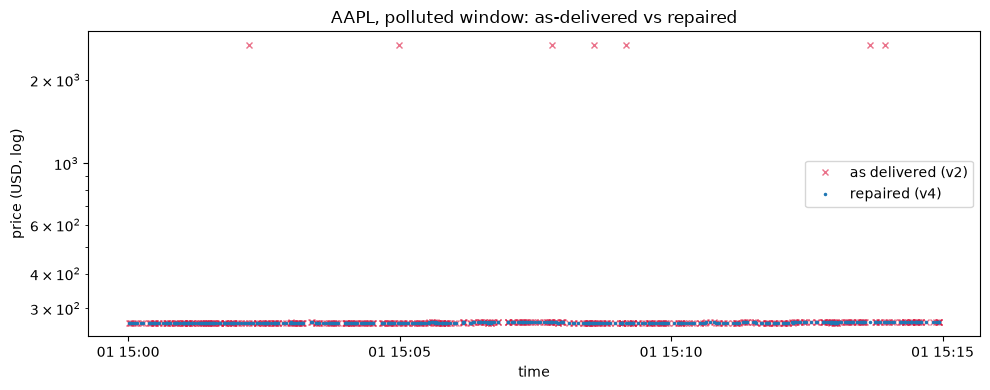

In [16]:
import matplotlib.pyplot as plt

raw_win = db.sql(
    f"""
    SELECT ts, price FROM h5i('trades', {V_RAW})
    WHERE symbol = 'AAPL' AND ts >= to_timestamp_micros({W0_US}) AND ts < to_timestamp_micros({W1_US})
    """
).to_pandas()
clean_win = db.sql(
    f"""
    SELECT ts, price FROM trades
    WHERE symbol = 'AAPL' AND ts >= to_timestamp_micros({W0_US}) AND ts < to_timestamp_micros({W1_US})
    """
).to_pandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_win["ts"], raw_win["price"], "x", ms=4, color="crimson", alpha=0.6,
        label=f"as delivered (v{V_RAW})")
ax.plot(clean_win["ts"], clean_win["price"], ".", ms=3, color="tab:blue",
        label=f"repaired (v{V_CLEAN})")
ax.set_yscale("log")
ax.set_title("AAPL, polluted window: as-delivered vs repaired")
ax.set_xlabel("time")
ax.set_ylabel("price (USD, log)")
ax.legend()
fig.tight_layout()

## 6. Over-cleaned? `restore()` is the undo button

Suppose an eager second pass deletes a window that turns out to be
legitimate volatility. Because the deletion is just another version,
rolling back is `restore()`, which moves the head *forward* to a new
version with the old content. Nothing is ever lost, including the mistake
itself.

In [17]:
bad0 = int(pd.Timestamp("2026-06-02 14:00", tz="UTC").value // 1_000)
bad1 = int(pd.Timestamp("2026-06-02 14:10", tz="UTC").value // 1_000)
oops = db.plan_delete_range("trades", bad0, bad1, note="overzealous: deleting real volatility")
oops.apply()
print("rows after over-delete:", db.sql("SELECT count(*) n FROM trades").to_pandas().n[0])

db.restore("trades", V_CLEAN)
print("rows after restore:   ", db.sql("SELECT count(*) n FROM trades").to_pandas().n[0])
[{k: v[k] for k in ("sequence", "op", "rows", "note") if k in v} for v in db.versions("trades")[-3:]]

rows after over-delete: 114032
rows after restore:    118213


[{'sequence': 4,
  'op': 'replace_range',
  'rows': 118213,
  'note': 'repair 15:00-15:15 window: /10 fat fingers, drop zeros+dups'},
 {'sequence': 5,
  'op': 'delete_range',
  'rows': 114032,
  'note': 'overzealous: deleting real volatility'},
 {'sequence': 6,
  'op': 'restore',
  'rows': 118213,
  'note': 'restore of version 4'}]

## 7. Lock the table down: plans only

On a shared research database you want *nobody* (junior, cron job, or
LLM agent) running unreviewed destructive writes. `set_policy` gates the
direct mutation paths; the plan/apply flow (which forces a previewable,
noted, atomic commit) keeps working. A gated call raises `PolicyError`
with a machine-readable code and a remediation hint:

In [18]:
print("policy before:", db.policy())
db.set_policy(direct_write=False, direct_delete=False)

try:
    db.write("trades", db.read("trades"))
except h5i_db.PolicyError as e:
    print(f"\nblocked: code={e.code}\nhint: {e.hint}")

policy before: {'direct_append': True, 'direct_write': True, 'direct_replace': True, 'direct_delete': True, 'direct_restore': True, 'direct_compact': True}

blocked: code=policy_violation
hint: run the write with --plan to preview it, review, then `h5i-db plan apply`; or relax the policy with `h5i-db policy set`


Pending plans are durable objects too: they show up in `list_plans()`
for teammates to review, survive process restarts, and expire after 7 days
if never applied (vacuum won't collect segments a live plan references).

In [19]:
pending = db.plan_delete_range("trades", bad0, bad1, note="for review: is 14:00-14:10 real?")
print([(p.plan_id, p.raw["note"]) for p in db.list_plans("trades")])
pending.discard()
print("after discard:", db.list_plans("trades"))

[('f746690c-fa17-4910-87d3-8a861ea443df', 'for review: is 14:00-14:10 real?')]
after discard: []


## Takeaways

- Each defect class is one SQL query: predicates for zeros and session
  hours, `approx_percentile_cont` medians for fat fingers, GROUP BY/HAVING
  for replayed packets.
- `plan_delete_range` / `plan_replace_range` make corrections *reviewable
  before they happen* (summary, before/after samples), then land them as
  atomic, noted commits. Ranges are raw microseconds of the time column.
- The version chain is the audit trail: as-delivered data stays queryable
  (`h5i('trades', v)`), diffs are SQL joins, and `restore()` undoes
  over-cleaning without losing the record that it happened.
- `set_policy(direct_write=False, direct_delete=False)` turns "please don't
  hot-fix production tables" from a convention into a `PolicyError`.

In [20]:
db.close()